# vi.ve — Trial 01 Review: *Riding Trap*

**Run date:** 2026-07-13 · **Generator:** `generate_vibes.py` v1 (weighted bar collage) · **Output:** 24 MIDI files (8 combos × melody/bassline/drums)

## Executive summary

| | |
|---|---|
| **Success metric** | files marked *keep* in `manifest.csv` |
| **Result** | **0 / 24 kept → Trial 01 = failure** |
| **But** | failure is concentrated in ONE component |

Component-level verdicts from auditioning:

| Component | Verdict | Notes |
|---|---|---|
| Basslines | ✅ strong | live in the sub lane, work played on 808s — style named **"Riding Trap"**, exemplar **v04** |
| Drums | ✅ good | complement the 808 well |
| Melodies | ❌ rejected | sound like **channel surfing** |

This notebook does four things: **(1)** shows how the analysis data is stored in Postgres, **(2)** logs the trial scorecard, **(3)** uses the metrics to explain *why* basslines collage well and melodies don't, **(4)** shows the new `styles` registry that makes *Riding Trap* recreatable.

In [1]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", message=".*SQLAlchemy.*")

# ---- vi.ve chart theme (validated categorical palette; color follows the SONG everywhere)
SONG_COLORS = {"morning": "#2a78d6", "out there": "#1baf7a", "sicko mode": "#eda100"}
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
BLUE_RAMP = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "grid.color": GRID, "grid.linewidth": 0.8,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "font.family": "sans-serif", "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
})

DATA = Path("../data")
conn = psycopg2.connect(dbname="vive", port=5431)   # Postgres.app, local trust auth
q = lambda sql: pd.read_sql(sql, conn)
packs = json.loads((DATA / "parsed_packs.json").read_text())["songs"]
print("connected — vive @ localhost:5431 ·", len(packs), "packs loaded")

/Users/trell/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


connected — vive @ localhost:5431 · 3 packs loaded


## 1 · How the data is stored

Everything lives in the local `vive` database in **long (tidy) format** — one observation per row, exactly like a fact table. `scope` is the grain: a single part (`hihat`), or an instrument *pair* for relationship metrics (`kick|bassline`). `run_date` + `source_file` make every analysis run append-only, so history accumulates instead of overwriting — the same pattern as a slowly-growing metrics mart.

In [2]:
q("SELECT id, run_date, song, scope, metric, value_num, value_text, source_file FROM metrics ORDER BY id LIMIT 8")

,id,run_date,song,scope,metric,value_num,value_text,source_file
0,1,2026-07-13,morning,bassline,space_ratio,0.0000,None,intra_pack_metrics.csv
1,2,2026-07-13,morning,bassline,onset_density_per_bar,5.2500,None,intra_pack_metrics.csv
2,3,2026-07-13,morning,bassline,velocity_reliable,0.0000,None,intra_pack_metrics.csv
3,4,2026-07-13,morning,bassline,timing_played,1.0000,None,intra_pack_metrics.csv
4,5,2026-07-13,morning,bassline,mean_abs_deviation_ms,2.9100,None,intra_pack_metrics.csv
5,6,2026-07-13,morning,bassline,longest_gap_beats,1.5000,None,intra_pack_metrics.csv
6,7,2026-07-13,morning,bassline,syncopation_lhl,0.9050,None,intra_pack_metrics.csv
7,8,2026-07-13,morning,chord progression,space_ratio,0.0163,None,intra_pack_metrics.csv


Standard rollup — `GROUP BY metric` works the way you'd expect a tidy fact table to:

In [3]:
q("""
SELECT metric,
       count(*)                          AS observations,
       round(avg(value_num)::numeric, 3) AS mean,
       round(min(value_num)::numeric, 3) AS min,
       round(max(value_num)::numeric, 3) AS max
FROM metrics
WHERE value_num IS NOT NULL AND song <> 'ALL'
GROUP BY metric
ORDER BY observations DESC
LIMIT 12
""")

,metric,observations,mean,min,max
0,mean_abs_deviation_ms,19,4.819,0.00,27.26
1,velocity_reliable,19,0.158,0.00,1.00
2,timing_played,19,0.368,0.00,1.00
3,longest_gap_beats,19,2.218,0.25,8.00
4,onset_density_per_bar,19,7.914,0.50,30.00
5,syncopation_lhl,19,0.785,0.00,2.00
6,space_ratio,19,0.485,0.00,0.97
7,ktb_mean_lag_ticks,4,-0.013,-0.05,0.00
8,ktb_lag_std_ticks,4,0.208,0.00,0.83
9,ktb_co_hit_rate,4,0.898,0.64,1.00


The style profile (position consensus, shared rhythm phrases, target zones) is stored as **jsonb** in `style_profiles` — one row per run. jsonb lets us unnest it relationally when needed. Here: every rhythm phrase shared across songs, straight out of the JSON document — `jsonb_each` + `jsonb_array_elements` are doing the unnesting:

In [4]:
ngrams = q("""
SELECT r.role,
       g->>'ioi_16ths'      AS ioi_phrase_16ths,
       (g->>'songs')::int   AS songs_sharing,
       (g->>'count')::int   AS occurrences
FROM style_profiles sp,
     jsonb_each(sp.profile->'roles') AS r(role, obj),
     jsonb_array_elements(r.obj->'shared_ioi_ngrams') AS g
WHERE sp.run_date = (SELECT max(run_date) FROM style_profiles)
ORDER BY songs_sharing DESC, occurrences DESC
""")
ngrams.head(10)

,role,ioi_phrase_16ths,songs_sharing,occurrences
0,hat,"[1, 1]",3,152
1,hat,"[1, 1, 1]",3,139
2,kick,"[3, 3]",3,36
3,bass,"[3, 1]",3,7
4,chords,"[1, 1]",2,33
5,hat,"[0, 0]",2,30
6,chords,"[1, 1, 1]",2,19
7,hat,"[0, 0, 0]",2,19
8,bass,"[3, 3]",2,18
9,clap,"[8, 8]",2,12


> Reading the top row: the kick's most-shared phrase is IOI `[3, 3]` in 16ths — **dotted-8th → dotted-8th, the tresillo cell** — present in all 3 songs, 36 times. Keep that in mind for section 3.

## 2 · Trial 01 scorecard

In [5]:
manifest = pd.read_csv(Path.home() / "Music/Ableton/User Library/vibes forever/manifest.csv")
keeps = (manifest["keep (y/n)"].str.strip().str.lower() == "y").sum()
print(f"keep rate: {keeps}/{len(manifest)} = {keeps/len(manifest):.0%}   →  Trial 01 logged as a FAILURE (melodies)")
manifest.head(6)

keep rate: 0/24 = 0%   →  Trial 01 logged as a FAILURE (melodies)


,combo,file,key,bpm,weights,keep (y/n)
0,v01,v01 - melody.mid,Em,71.66,morning:1.0 out there:0.0 sicko mode:0.0,n
1,v01,v01 - bassline.mid,Em,71.66,morning:1.0 out there:0.0 sicko mode:0.0,n
2,v01,v01 - drums.mid,Em,71.66,morning:1.0 out there:0.0 sicko mode:0.0,n
3,v02,v02 - melody.mid,Ebm,80.00,morning:0.0 out there:1.0 sicko mode:0.0,n
4,v02,v02 - bassline.mid,Ebm,80.00,morning:0.0 out there:1.0 sicko mode:0.0,n
5,v02,v02 - drums.mid,Ebm,80.00,morning:0.0 out there:1.0 sicko mode:0.0,n


All 24 files rejected **as combos** — but the rejection reason was the melody component every time. The basslines were good enough to *name a style after* (Riding Trap). So the interesting analytical question isn't "did it fail" — it's:

## 3 · Root cause — why basslines ride and melodies channel-surf

**The generator's core assumption:** v1 builds each new pattern by sampling *whole bars* from the source songs (weighted dice per bar). That's only valid if bars are **exchangeable across songs** — i.e., the between-song variance of a role's musical features is low. If song A's "melody" and song B's "melody" are fundamentally different objects, splicing their bars produces exactly what it sounds like: channel surfing.

So: measure between-song variance per role. First, what the generator actually sampled from — each role's *source pool*:

| Generated role | morning source | out there source | sicko mode source |
|---|---|---|---|
| bass | bassline | verse bassline | bassline |
| melody | **chord progression** | **verse keys (plucky arp)** | **main melody (sparse lead)** |
| kick / snare / hat | kick / snare / hihat | kick / snare / hihat | kick / snare / hihat |

The melody row should already look suspicious — those are three different *kinds* of instrument part. The metrics quantify it:

In [6]:
BASS_POOL   = {"morning": "bassline",          "out there": "verse bassline", "sicko mode": "bassline"}
MELODY_POOL = {"morning": "chord progression", "out there": "verse keys",     "sicko mode": "main melody"}
DRUM_POOLS  = {"kick": "kick", "snare": "snare", "hat": "hihat"}

def find_part(song, scope):
    for p in packs[song]["parts"]:
        name = p["part"] if p["section"] == "both" else f"{p['section']} {p['part']}"
        if name == scope:
            return p

m = q("SELECT song, scope, metric, value_num FROM metrics WHERE source_file = 'intra_pack_metrics.csv'")

rows = []
for song in SONG_COLORS:
    pools = {"bass": BASS_POOL[song], "melody": MELODY_POOL[song], **DRUM_POOLS}
    for role, scope in pools.items():
        sub = m[(m.song == song) & (m.scope == scope)].set_index("metric").value_num
        part = find_part(song, scope)
        if sub.empty or part is None:
            continue
        pitches = [n["pitch"] for n in part["notes"]]
        rows.append({"song": song, "role": role,
                     "onset_density_per_bar": sub.get("onset_density_per_bar"),
                     "space_ratio": sub.get("space_ratio"),
                     "syncopation": sub.get("syncopation_lhl"),
                     "register_center": round(np.mean(pitches), 1),
                     "register_width": max(pitches) - min(pitches)})
feat = pd.DataFrame(rows)
feat

,song,role,onset_density_per_bar,space_ratio,syncopation,register_center,register_width
0,morning,bass,5.25,0.0000,0.905,38.2,17
1,morning,melody,30.00,0.0163,0.387,74.9,47
2,morning,kick,5.00,0.8887,0.950,60.0,0
3,morning,snare,1.50,0.9701,1.667,60.0,0
4,morning,hat,20.00,0.6966,0.414,59.5,12
5,out there,bass,5.50,0.0000,0.273,46.4,7
6,out there,melody,10.00,0.4089,0.100,66.9,8
7,out there,kick,4.50,0.6562,0.889,60.0,0
8,out there,snare,0.50,0.9583,2.000,60.0,0
9,out there,hat,18.00,0.0000,0.000,60.0,0


### 3.1 · Density: the melody pool is three different instruments in disguise

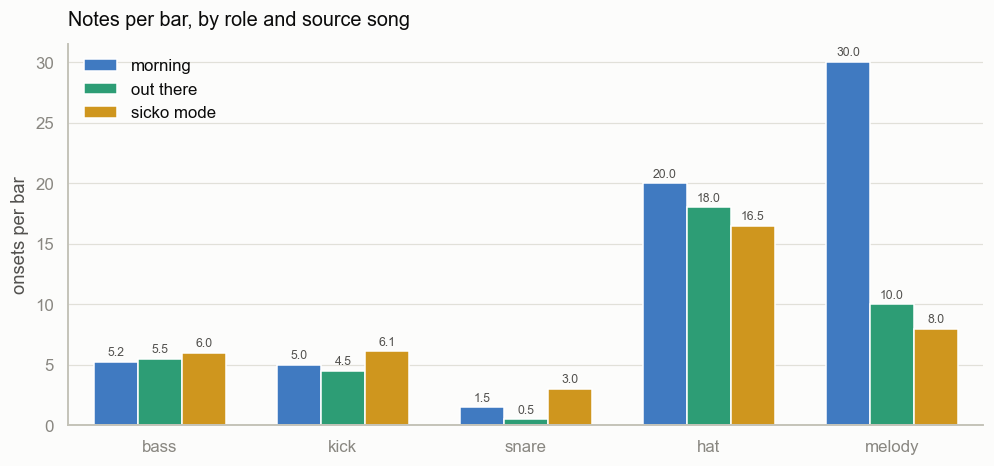

In [7]:
order = ["bass", "kick", "snare", "hat", "melody"]
fig, ax = plt.subplots(figsize=(9.2, 4.4))
sns.barplot(data=feat, x="role", y="onset_density_per_bar", hue="song",
            order=order, hue_order=list(SONG_COLORS), palette=SONG_COLORS, ax=ax, width=0.72)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f", fontsize=8, color=INK2, padding=2)
ax.set_title("Notes per bar, by role and source song", loc="left", fontsize=13, pad=12)
ax.set_xlabel("")
ax.set_ylabel("onsets per bar")
ax.legend(frameon=False, title="")
plt.tight_layout()
plt.show()

Bass sits at **5.3 / 5.5 / 6.0** notes per bar across all three songs — practically interchangeable. The melody pool spans **30 / 10 / 8**: morning's contribution is a dense chord progression carrying ~3–4× the event rate of the other two. Every time the collage dice switched a bar between morning ↔ sicko, the listener heard the texture jump by 4× — that *is* the channel-surf.

### 3.2 · Space: same story from the silence side

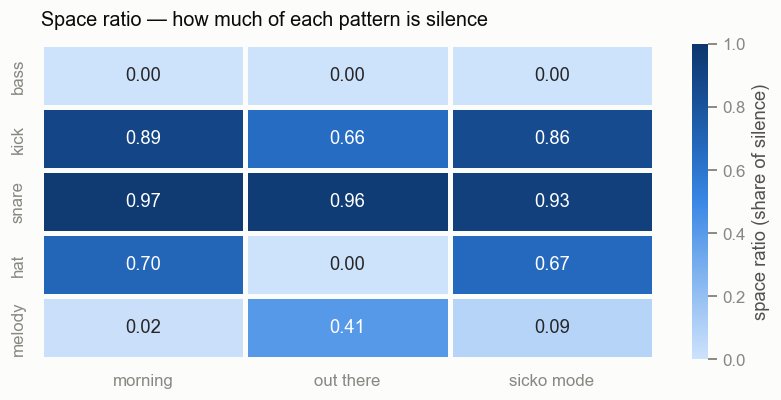

In [8]:
piv = feat.pivot(index="role", columns="song", values="space_ratio").loc[order, list(SONG_COLORS)]
fig, ax = plt.subplots(figsize=(7.6, 3.8))
sns.heatmap(piv, annot=True, fmt=".2f", vmin=0, vmax=1,
            cmap=sns.blend_palette(BLUE_RAMP, as_cmap=True),
            linewidths=2, linecolor=SURFACE, cbar_kws={"label": "space ratio (share of silence)"}, ax=ax)
ax.set_title("Space ratio — how much of each pattern is silence", loc="left", fontsize=13, pad=12)
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.show()

Every drum role keeps a consistent space budget across songs (each **row** is near-uniform — read rows, not columns). Bass is 0.00 everywhere: continuous sub sustain, which is precisely the *Riding Trap* signature. Melody goes **0.02 → 0.41 → 0.09**: one source barely breathes, another is 41% air. Splice those and the *space budget* lurches bar to bar — space is a first-class pocket feature (the readme's thesis), and the collage was randomizing it.

### 3.3 · Register: melodies also jump octaves at the splice points

/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/Users/trell/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated 

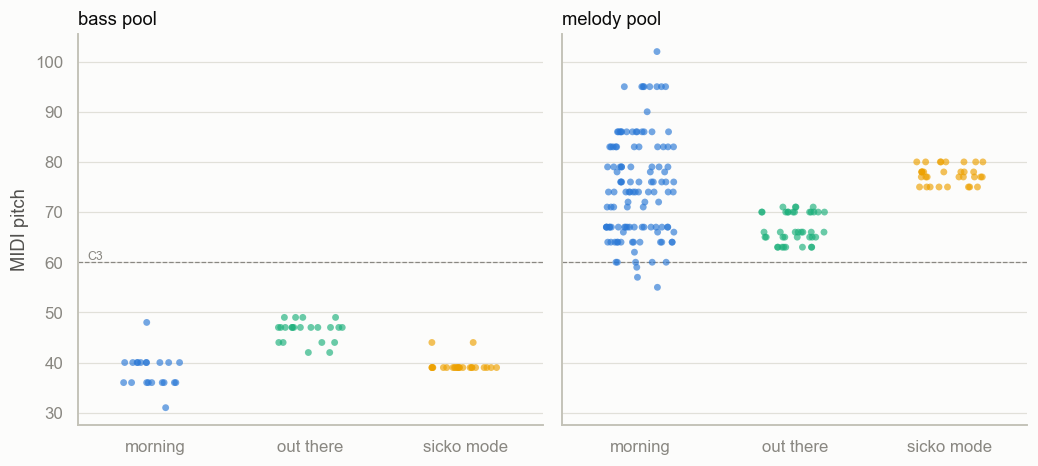

In [9]:
reg_rows = []
for pool_name, pool in [("bass pool", BASS_POOL), ("melody pool", MELODY_POOL)]:
    for song, scope in pool.items():
        part = find_part(song, scope)
        for n in part["notes"]:
            reg_rows.append({"pool": pool_name, "song": song, "pitch": n["pitch"]})
reg = pd.DataFrame(reg_rows)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 4.4), sharey=True)
for ax, pool_name in zip(axes, ["bass pool", "melody pool"]):
    sns.stripplot(data=reg[reg.pool == pool_name], x="song", y="pitch", hue="song",
                  order=list(SONG_COLORS), palette=SONG_COLORS, legend=False,
                  size=4.5, alpha=0.65, jitter=0.22, ax=ax)
    ax.set_title(pool_name, loc="left", fontsize=12)
    ax.axhline(60, color=MUTED, lw=0.8, ls="--")
    ax.set_xlabel(""); ax.set_ylabel("MIDI pitch")
axes[0].annotate("C3", xy=(0.02, 60), xycoords=("axes fraction", "data"),
                 fontsize=8, color=MUTED, va="bottom")
plt.tight_layout()
plt.show()

Bass notes from all three songs live in one tight low band — swap bars and the 808 line never leaves the sub lane. The melody pool occupies **three different registers** (and morning's is a chord *cloud*, not a line). Bar splices therefore jump register mid-phrase — the second ingredient of channel surfing.

### 3.4 · Shared rhythm vocabulary: bass bars speak the same language, melody bars don't

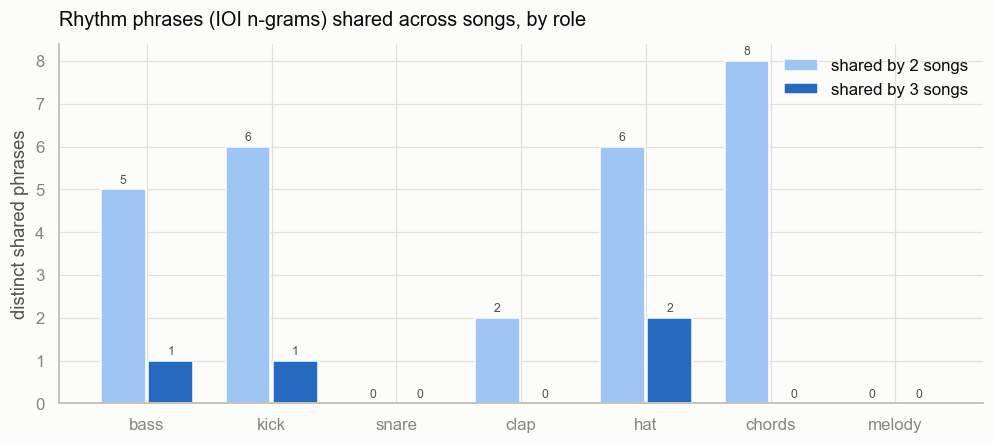

In [10]:
overlap = (ngrams.groupby(["role", "songs_sharing"]).size().unstack(fill_value=0)
           .reindex(["bass", "kick", "snare", "clap", "hat", "chords", "melody"]).fillna(0))
fig, ax = plt.subplots(figsize=(9.2, 4.2))
x = np.arange(len(overlap))
shades = {2: BLUE_RAMP[1], 3: BLUE_RAMP[4]}
width = 0.38
for i, col in enumerate([c for c in (2, 3) if c in overlap.columns]):
    bars = ax.bar(x + (i - 0.5) * width, overlap[col], width * 0.94,
                  color=shades[col], label=f"shared by {col} songs")
    ax.bar_label(bars, fmt="%.0f", fontsize=8, color=INK2, padding=2)
ax.set_xticks(x, overlap.index)
ax.set_title("Rhythm phrases (IOI n-grams) shared across songs, by role", loc="left", fontsize=13, pad=12)
ax.set_ylabel("distinct shared phrases")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Bass and kick have phrases shared by **all three songs** — including the tresillo `[3,3]` cell from section 1. They share a rhythmic grammar, so a collage of their bars still "speaks one language." The **melody role has zero shared phrases** — every source speaks its own dialect. (`chords` here = the chord-progression/keys parts that got drafted into the melody pool.)

### 3.5 · The punchline: collage compatibility index

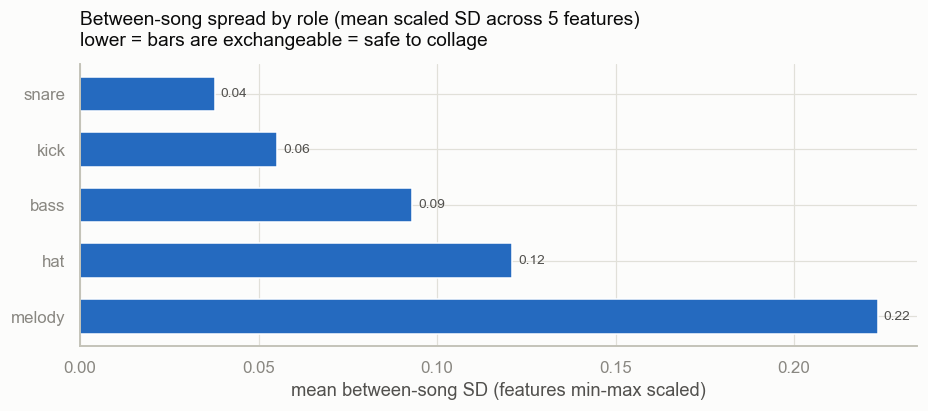

        onset_density_per_bar  space_ratio  syncopation  register_center  \
role                                                                       
bass                    0.011        0.000        0.250            0.092   
hat                     0.049        0.332        0.098            0.006   
kick                    0.023        0.106        0.137            0.000   
melody                  0.337        0.176        0.082            0.115   
snare                   0.035        0.017        0.136            0.000   

        register_width  
role                    
bass             0.112  
hat              0.120  
kick             0.010  
melody           0.407  
snare            0.000  


In [11]:
# Methodology note: raw CV misleads here — features with near-zero means (hat syncopation,
# bass space) blow the ratio up. Min-max scale each feature across all role-song rows first,
# then compare the between-song standard deviation on equal footing.
features = ["onset_density_per_bar", "space_ratio", "syncopation", "register_center", "register_width"]
scaled = feat.copy()
for f in features:
    lo, hi = feat[f].min(), feat[f].max()
    scaled[f] = (feat[f] - lo) / (hi - lo + 1e-9)
spread = scaled.groupby("role")[features].agg(lambda s: s.std(ddof=0))
idx = spread.mean(axis=1).sort_values()

fig, ax = plt.subplots(figsize=(8.6, 3.9))
bars = ax.barh(idx.index, idx.values, color=BLUE_RAMP[4], height=0.62)
ax.bar_label(bars, fmt="%.2f", fontsize=9, color=INK2, padding=4)
ax.set_title("Between-song spread by role (mean scaled SD across 5 features)\nlower = bars are exchangeable = safe to collage",
             loc="left", fontsize=12.5, pad=12)
ax.set_xlabel("mean between-song SD (features min-max scaled)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(spread.round(3))

**One number per role: how differently the three songs treat it.** The roles you kept (bass, kick, snare, hats) cluster at the low end — their bars are near-interchangeable, so weighted sampling produces coherent hybrids. Melody sits alone at the far end: the generator was sampling from three incompatible distributions and stitching the draws together. **The weighting system worked; the melody *pool* was invalid.** That's a data problem and an algorithm problem, not a weights problem — which is exactly why trial 2 doesn't touch the weighting.

(Per-feature table above shows the one nuance: hats do vary in *space* — out there's hat fills every 16th while the others breathe — but hats survived because their placement grammar is universal across songs, and hat identity lives in the roll/velocity layer, not in which 16ths are occupied.)

### Interpretation for trial 2

1. **Bass/drums keep the collage.** Their between-song variance is low and their shared grammar (tresillo) is real. This *is* the Riding Trap engine.
2. **Melody needs generation, not collage.** A melody carries motif identity — bar splices break contour continuity even when register/density match. Trial 2 should generate melody from the style profile's grammar (shared scale degrees, IOI vocabulary, target-zone density/space) and hold ONE register + ONE motif seed for all 4 bars.
3. **Data fix in parallel:** the melody pool needs likes — more hand-played lead lines in midi_university (especially once the MIDI keyboard cable is replaced) so melody has a real distribution to learn from.

## 4 · The style registry — making *Riding Trap* recreatable

New table `styles`: the style name you coin + a jsonb **recipe** (weights, key, bpm, generator version, and the exact per-bar source map of the exemplar). Recreating a style = feed the recipe back to the generator — no re-explaining required:

In [12]:
q("""
SELECT name, created, verdict,
       recipe->>'exemplar_combo' AS exemplar,
       recipe->'weights'         AS weights,
       recipe->>'key'            AS key,
       recipe->>'bpm'            AS bpm
FROM styles
""")

,name,created,verdict,exemplar,weights,key,bpm
0,riding trap,2026-07-13,"Trial 01: basslines strong (v04 exemplar), dru...",v04,"{'morning': 0.12, 'out there': 0.24, 'sicko mo...",Em,77.51


In [13]:
print(q("SELECT jsonb_pretty(recipe->'bar_sources') AS bar_map FROM styles WHERE name = 'riding trap'").bar_map[0])

{
    "hat": [
        "sicko mode",
        "out there",
        "sicko mode",
        "sicko mode"
    ],
    "bass": [
        "sicko mode",
        "morning",
        "sicko mode",
        "morning"
    ],
    "clap": [
        "out there",
        "morning",
        "out there",
        "out there"
    ],
    "kick": [
        "sicko mode",
        "sicko mode",
        "morning",
        "sicko mode"
    ],
    "snare": [
        "sicko mode",
        "sicko mode",
        "morning",
        "out there"
    ],
    "melody": [
        "sicko mode",
        "sicko mode",
        "sicko mode",
        "sicko mode"
    ]
}


The `bar_sources` map is the exact DNA of v04 — which song every single bar of every instrument came from. Between that, the weights, and the generator's fixed seeds, *Riding Trap v04* is reproducible from the database alone.

---

*Trial 01 closed: 0/24 keep rate, root cause isolated to the melody pool's between-song variance, style registry live. Next: grammar-based melody generation.*